**Вайцеховский Егор, 5130901/20102**

### *Упражнение 6.1.*

Необходимо исследовать функции для получения амплитуд - analyze1 и analyze2 и убедиться, что они требуют времени пропорционально n^3 и n^2 соответственно.

Код функций представлен ниже:

In [2]:
def analyze1(ys, fs, ts):
  args = np.outer(ts, fs)
  M = np.cos(PI2 * args)
  amps = np.linalg.solve(M, ys)
  return amps

def analyze2(ys, fs, ts):
  args = np.outer(ts, fs)
  M = np.cos(PI2 * args)
  amps = np.dot(M, ys) / 2
  return amps

Чтобы проверить факт, описанный выше, будем анализировать некоррелированный Гауссов шум. Форма волны на расчёты не влияет.

Код и получившийся шум выглядят следующим образом:


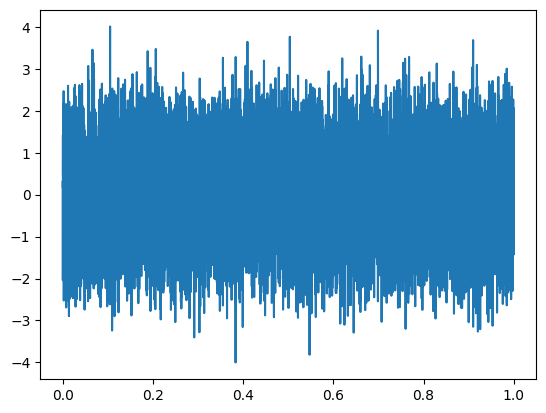

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate, PI2
from thinkdsp import UncorrelatedGaussianNoise

signal = UncorrelatedGaussianNoise()
noise = signal.make_wave(duration=1.0, framerate=16384)
noise.plot()

Теперь разработаем функцию для измерения времени:

In [4]:
def run_speed_test(ns, func):
    results = []
    for N in ns:
        print(N)
        ts = (0.5 + np.arange(N)) / N
        freqs = (0.5 + np.arange(N)) / 2
        ys = noise.ys[:N]
        result = %timeit -r1 -o func(ys, freqs, ts)
        results.append(result)

    bests = [result.best for result in results]
    return bests

И функцию для отрисовки результатов в логарифмической шкале, возвращающую наклон этой прямой:

In [5]:
from scipy.stats import linregress

loglog = dict(xscale='log', yscale='log')

def plot_bests(ns, bests):
    plt.plot(ns, bests)
    decorate(**loglog)

    x = np.log(ns)
    y = np.log(bests)
    t = linregress(x,y)
    slope = t[0]

    return slope

Для исследования создадим массив точек с измерениями.

Код и его вывод представлены ниже

In [6]:
ns = np.array(2 ** np.arange(6, 13), np.int64)
ns

array([  64,  128,  256,  512, 1024, 2048, 4096])

Протестируем функцию analyze1.

Получившийся график и результаты вычислений выглядят так:

64
1.29 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
128
2.26 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
256
3.58 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
512
18.7 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
85.8 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
441 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
4096
3.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


1.9288547782394945

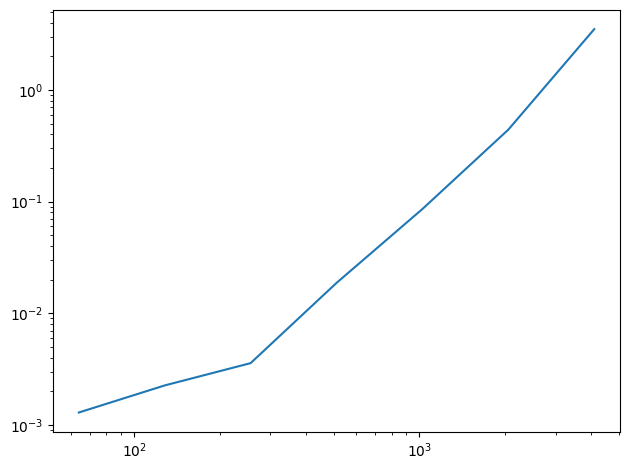

In [7]:
bests = run_speed_test(ns, analyze1)
plot_bests(ns, bests)

Основное интересующее нас значение – наклон графика. Ожидалось, что она будет близка к 3, но мы видим, что она чуть больше 2.

Такой результат может быть следствием разных причин, но вероятнее всего дело в np.linalg.solve, где точно присутствует ряд оптимизаций, ускоряющих работу функции.

Предположительно, достижение ожидаемой сложности возможно при увеличении n, но это потребует больше ресурсов, потому что даже с текущии входными данными, время ожидания составляет несколько секунд.


Протестируем функцию analyze2.

Получившийся график и результаты вычислений выглядят так:

64
116 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
128
1.31 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1000 loops each)
256
2.18 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
512
8.89 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 100 loops each)
1024
37.5 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
2048
220 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 10 loops each)
4096
598 ms ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


1.996275309551554

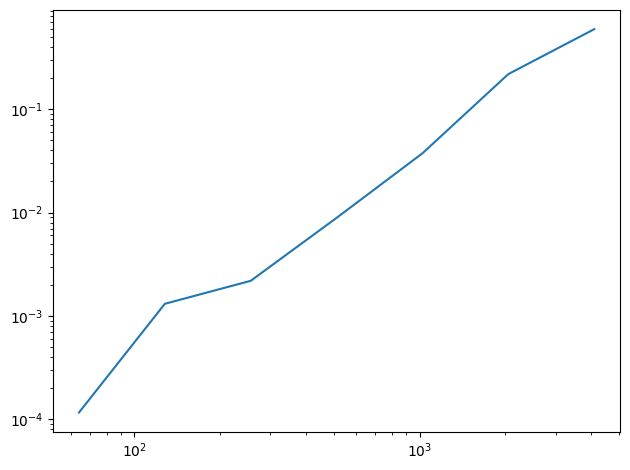

In [8]:
bests2 = run_speed_test(ns, analyze2)
plot_bests(ns, bests2)

Здесь, как и ожидалось, наклон близок к 2, а время выполнения программы значительно ниже, что тоже является плюсом для дальнейшей работы.

Теперь повторим те же расчеты с функцией dct из scipy.fftpack.

Получившийся график и расчёты выглядят следующим образом:


In [9]:
import scipy.fftpack

def scipy_dct(ys, fs, ts):
    return scipy.fftpack.dct(ys, type=2)

64
6.29 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
128
7.27 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
256
7.84 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
512
12.9 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 100000 loops each)
1024
23.1 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
2048
36.9 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)
4096
55.2 µs ± 0 ns per loop (mean ± std. dev. of 1 run, 10000 loops each)


0.5586256621670237

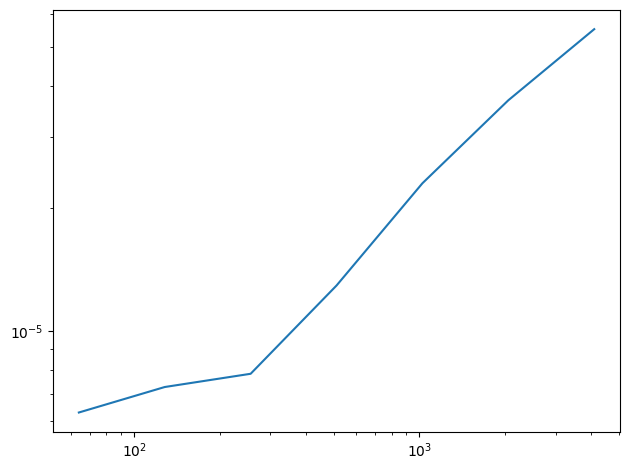

In [10]:
bests3 = run_speed_test(ns, scipy_dct)
plot_bests(ns, bests3)

По результатам работы данной функции отметим, что время выполнения значительно меньше, чем у предыдущих двух функций.

Так же обратим внимание на угол наклона функции. Получившееся значение свидетельствует о сложности nlog(n), об этом нам говорит и документация к методу.

Для сравнения выведем все три графика на одном листе.

Получившийся рисунок представлен ниже:

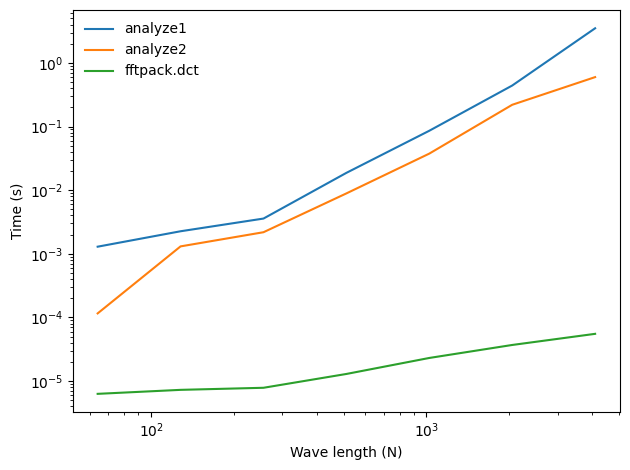

In [11]:
plt.plot(ns, bests, label='analyze1')
plt.plot(ns, bests2, label='analyze2')
plt.plot(ns, bests3, label='fftpack.dct')
decorate(xlabel='Wave length (N)', ylabel='Time (s)', **loglog)

### *Упражнение 6.2.*

Одно из основных применений ДКП – это сжатие звука и изображений. В простейшей форме ДКП при сжатии работает следующим образом:
1.	Разбивает длинный сигнал на сегменты.
2.	Вычисляет ДКП каждого сегмента.
3.	Определяет частотные компоненты с такой амплитудой, что их не слышно, и удаляет их, сохраняя только оставшиеся частоты и амплитуды.
4.	При воспроизведении сигнала загружает частоты и амплитуды каждого сегмента и применяет обратное ДКП.

Реализуем версию этого алгоритма для записи саксофона.

Сначала прочитаем запись:


In [14]:
from thinkdsp import read_wave, decorate
import numpy as np

wave = read_wave('100475__iluppai__saxophone-weep.wav')
wave.make_audio()

Теперь применим алгоритм к одному сегменту, чтобы потом создать функцию, распространяющую наше решение на всю запись.

1. Получим сегмент произведения
2. Посчитаем ДКП
3. Выведем на экран

Результат алгоритма приведён ниже:



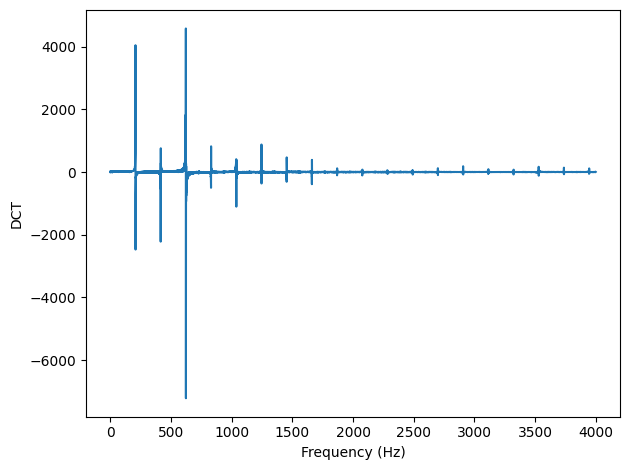

In [31]:
segment = wave.segment(start=1, duration=0.5)
segment.normalize()
seg_dct = segment.make_dct()
seg_dct.plot(high=4000)
decorate(xlabel='Frequency (Hz)', ylabel='DCT')
segment.make_audio()

Далее напишем функцию (п.3), которая будет выявлять частотные компоненты с маленькой амплитудой и удалять их.
Дополнительно она будет выводить, сколько значений было удалено и сколько они составляют процентов от общего числа.

Код функции выглядит так:

In [32]:
def compress(dct, thresh=1):
    count = 0
    for i, amp in enumerate(dct.amps):
        if np.abs(amp) < thresh:
            dct.hs[i] = 0
            count += 1

    n = len(dct.amps)
    print(count, n, 100 * count / n, sep='\t')

Итоговый график ДКП:

20292	22050	92.02721088435374


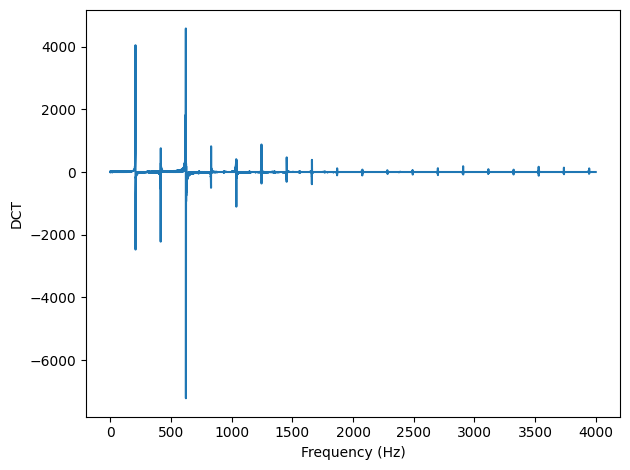

In [33]:
compress(seg_dct, thresh=10)
seg_dct.plot(high=4000)
decorate(xlabel='Frequency (Hz)', ylabel='DCT')
seg2 = seg_dct.make_wave()
seg2.make_audio()

Визульно график не изменился, аудиозапись тоже не отличается от изначальной. Однако, численные результаты, которые вывела функция говорят о том, что в ходе её работы было удалено 92% сегментов, которые мы не слышим.

Именно поэтому данный метод такой эффективный - он практически не заметен для человеческого слуха, но очень экономит занимаемый информацией объём памяти.


Теперь необходимо реализовать алгоритм, работающий с сегментами большей длинны.

Выполним разбиение на сегменты с ДКП:

In [34]:
from thinkdsp import Spectrogram

def make_dct_spectrogram(wave, seg_length):
    window = np.hamming(seg_length)
    i, j = 0, seg_length
    step = seg_length // 2
    # map from time to Spectrum
    spec_map = {}

    while j < len(wave.ys):
        segment = wave.slice(i, j)
        segment.window(window)

        # the nominal time for this segment is the midpoint
        t = (segment.start + segment.end) / 2
        spec_map[t] = segment.make_dct()

        i += step
        j += step

    return Spectrogram(spec_map, seg_length)

Здесь необходимо использовать окно Хемминга, которое рассматривалось в предыдущих лабораторных.

Мы разбили аудио на сегменты, теперь применим функцию «сжатия» на каждый из этих сегментов:


In [46]:
spectro = make_dct_spectrogram(wave, seg_length=1024)
for t, dct in sorted(spectro.spec_map.items()):
    compress(dct, thresh=0.2)

1018	1024	99.4140625
1016	1024	99.21875
1014	1024	99.0234375
1017	1024	99.31640625
1016	1024	99.21875
1017	1024	99.31640625
1016	1024	99.21875
1020	1024	99.609375
1014	1024	99.0234375
1005	1024	98.14453125
1009	1024	98.53515625
1015	1024	99.12109375
1015	1024	99.12109375
1016	1024	99.21875
1016	1024	99.21875
1015	1024	99.12109375
1017	1024	99.31640625
1020	1024	99.609375
1013	1024	98.92578125
1017	1024	99.31640625
1013	1024	98.92578125
1017	1024	99.31640625
1018	1024	99.4140625
1015	1024	99.12109375
1013	1024	98.92578125
794	1024	77.5390625
785	1024	76.66015625
955	1024	93.26171875
995	1024	97.16796875
992	1024	96.875
976	1024	95.3125
925	1024	90.33203125
802	1024	78.3203125
836	1024	81.640625
850	1024	83.0078125
882	1024	86.1328125
883	1024	86.23046875
891	1024	87.01171875
901	1024	87.98828125
902	1024	88.0859375
900	1024	87.890625
900	1024	87.890625
894	1024	87.3046875
904	1024	88.28125
901	1024	87.98828125
915	1024	89.35546875
913	1024	89.16015625
899	1024	87.79296875
905	1024	88.37

Прослушаем получившуюся волну:

In [47]:
wave2 = spectro.make_wave()
wave2.make_audio()

Аудиозапись практически не поменяла своё звучание, однако из неё было удалено практически 95% - 96% сегментов, что сильно упрощает хранение этой информации, но добавляет в запись некоторое "дребезжание", и звук, очевидно, уже не такой красивый и чистый.

В написанной для данного задания функции главное - правильно найти баланс между звучанием и удалением информации. Например, при thresh = 1 "дребезжание" на фоне достаточно заметно, но исходная запись хорошо различима, а при thresh = 10 запись практически не похожа на то, что мы слышали изначально, однако к этому моменту удаляется уже более 98% информации.


### *Упражнение 6.3.*

В этом упражнении нам необходимоо ответить на вопрос: слышим ли мы изменения в фазе сигнала.

Для начала исследуем уже знакомый нам пилообразный сигнал. Его график мы встречали, он выглядит так:


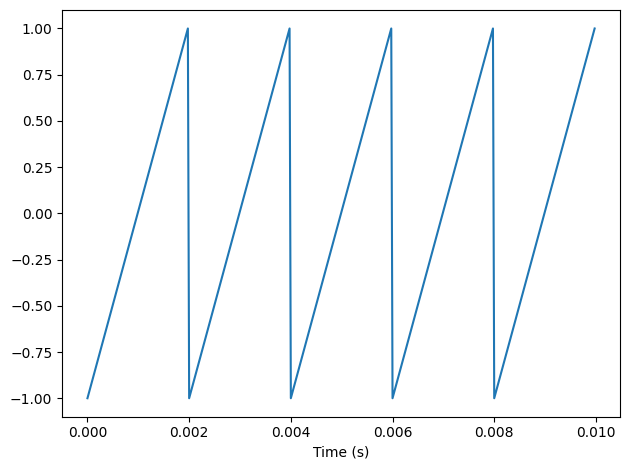

In [82]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate, PI2, read_wave
from thinkdsp import SawtoothSignal

signal = SawtoothSignal(freq=500, offset=0)
wave = signal.make_wave(duration=0.5, framerate=40000)
wave.segment(duration=0.01).plot()
decorate(xlabel='Time (s)')
wave.make_audio()

Теперь выведем спектр этого сигнала:


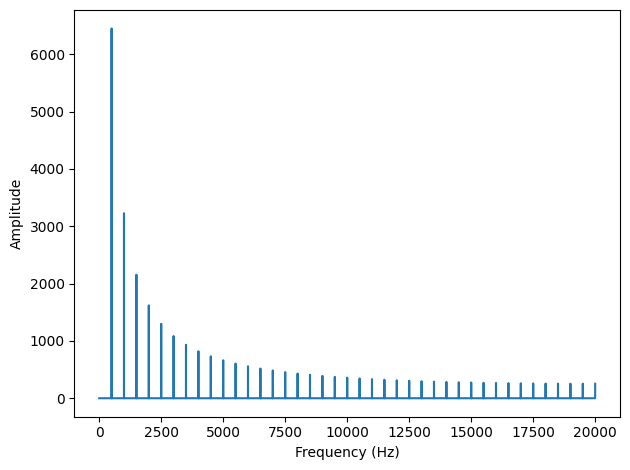

In [83]:
spectrum = wave.make_spectrum()
spectrum.plot()
decorate(xlabel='Frequency (Hz)',
         ylabel='Amplitude')

Далее выведем новый для нас график - график углов спектра.

Данная функция выводит все углы, выше заданного порога.

Попробуем напечатать этот график без порога (0) и получим следующий результат:

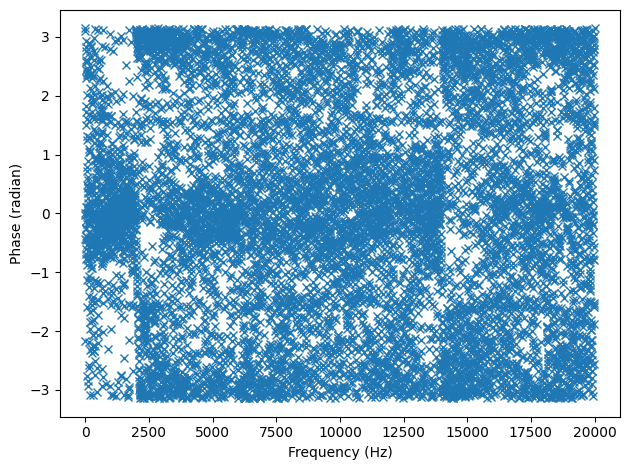

In [84]:
def plot_angle(spectrum, thresh=1):
    angles = spectrum.angles
    angles[spectrum.amps < thresh] = np.nan
    plt.plot(spectrum.fs, angles, 'x')
    decorate(xlabel='Frequency (Hz)',
             ylabel='Phase (radian)')

plot_angle(spectrum, thresh=0)

Полученный график кажется хаотичным, но, если увеличить порог до 1, мы видим абсолютно другой результат:

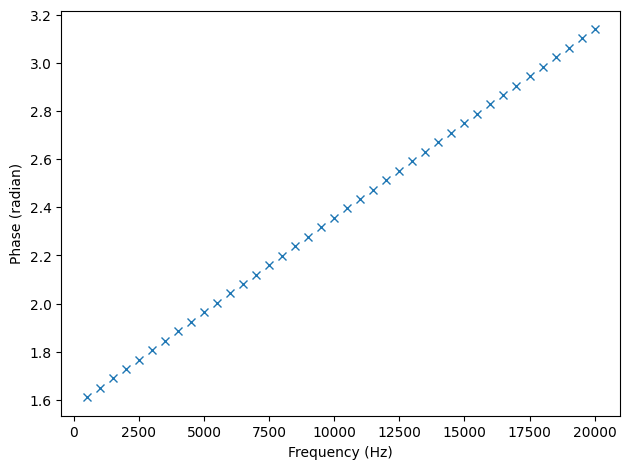

In [85]:
plot_angle(spectrum, thresh=1)

На графике мы видим, что каждая гармоника смещена относительно предыдущей на долю радиана.

Теперь напишем функцию, которая будет выводить все три 3 графика, а также аудио переданного спектра.

Код и его вывод для выбранного ранее сегмента приведены ниже:


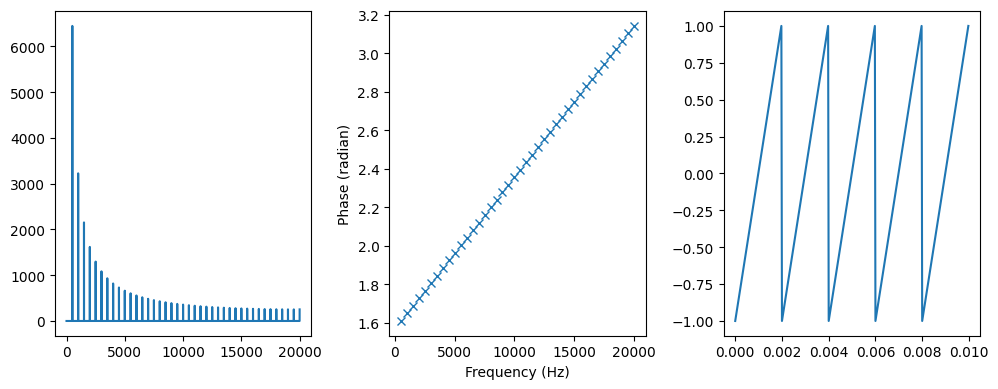

In [86]:
def plot_three(spectrum, thresh=1):
    plt.figure(figsize=(10, 4))
    plt.subplot(1,3,1)
    spectrum.plot()
    plt.subplot(1,3,2)
    plot_angle(spectrum, thresh=thresh)
    plt.subplot(1,3,3)
    wave = spectrum.make_wave()
    wave.unbias()
    wave.normalize()
    wave.segment(duration=0.01).plot()
    display(wave.make_audio())

plot_three(spectrum)

Попробуем изменить углы - посмотрим, как это влияет на звучание.

Первым делом занулим эти углы:


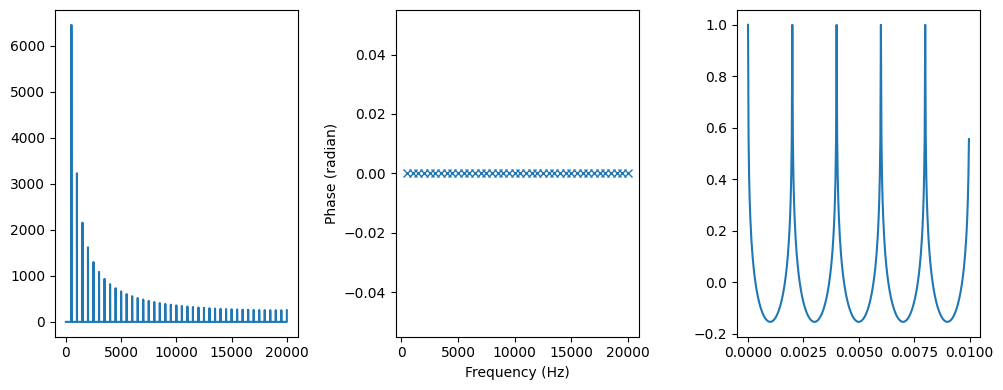

In [87]:
def zero_angle(spectrum):
    res = spectrum.copy()
    res.hs = res.amps
    return res
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2)

Звук не изменился, но стал немного тише - это результат нормализации.
Т. е. при изменении угла на 0, мы получили абсолютно тот же звук.

Теперь умножим наши углы на *exp⁡(iφ)*, это добавит *φ* к углу.

Полученные графики приведены ниже:


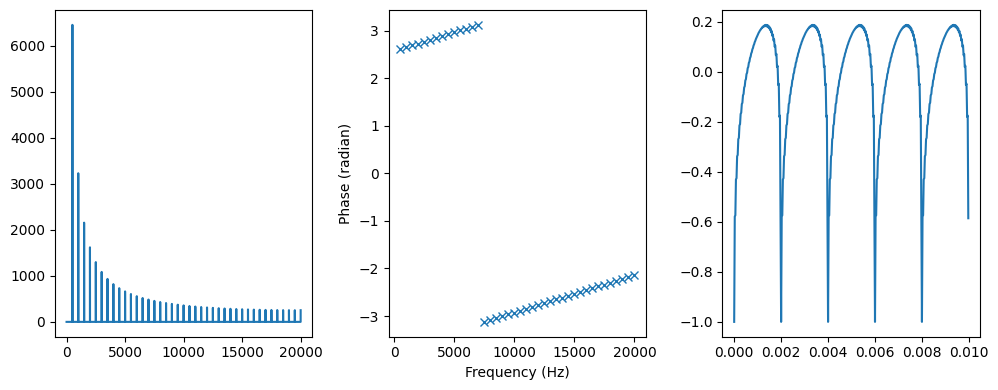

In [88]:
def rotate_angle(spectrum, offset):
    res = spectrum.copy()
    res.hs *= np.exp(1j * offset)
    return res

spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3)

Как мы можем слышать, не произошло никакого изменения в звучании.
Попробуем выполнить случайное смещение.

Полученные графики выглядят так:


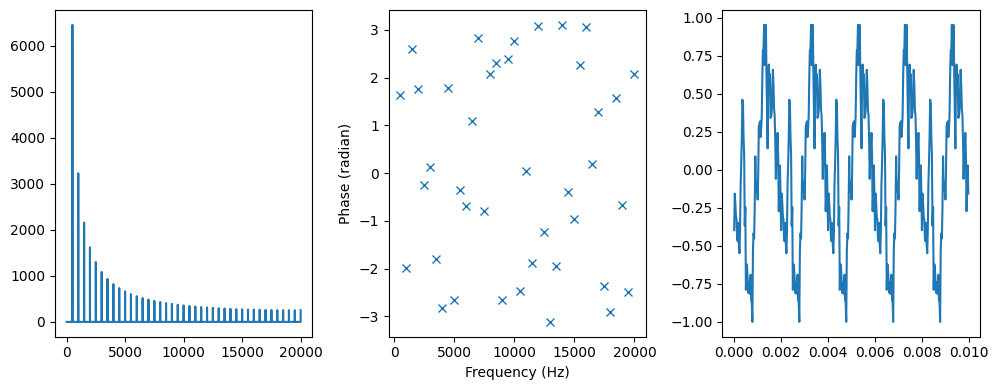

In [89]:
def random_angle(spectrum):
    res = spectrum.copy()
    angles = np.random.uniform(0, PI2, len(spectrum))
    res.hs *= np.exp(1j * angles)
    return res
spectrum4 = random_angle(spectrum)
plot_three(spectrum4)

Хоть графики и изменились, у нас снова получился тот же звук, только чуть громче.

Возможно, звук слишком простой. Возьмем звук гобоя и повторим эксперимент:


In [90]:
wave = read_wave('120994__thirsk__120-oboe.wav')
wave.make_audio()

Выберем сегмент длительностью 0.9 и распечатаем для него все те же графики:


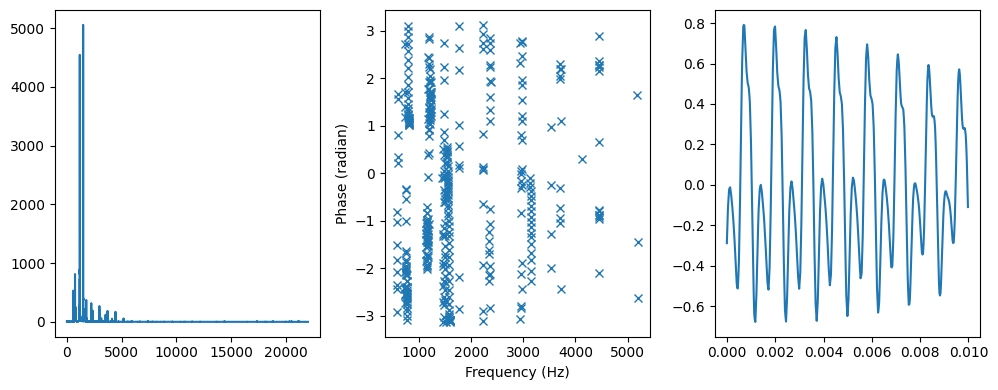

In [91]:
segment = wave.segment(start=1, duration=0.9)
spectrum = segment.make_spectrum()
plot_three(spectrum, thresh=50)

Теперь заменим угол на 0, вызовом функции zero_angle:


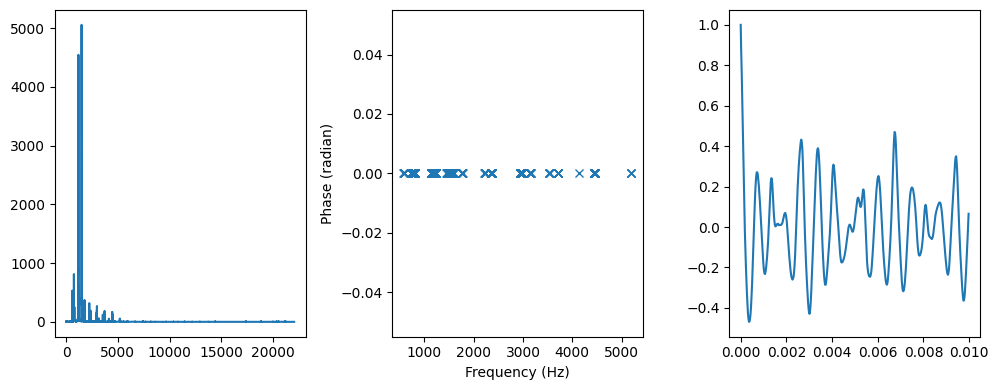

In [92]:
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

Звук очень изменился - начало фрагмента практически не слышно, постепенно он восстанавливает исходный уровень громкости, но исходная мелодия совсем не узнается в получившейся записи.

Посмотрим, какой результат будет со смещением фазы:


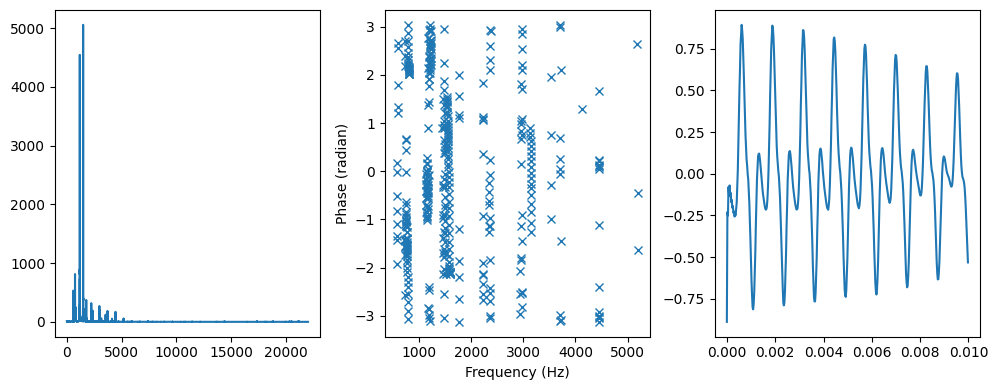

In [93]:
spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3, thresh=50)

После применения функции смещения фазы звук аналогичен исходному.

Попробуем применить функцию random_angle:


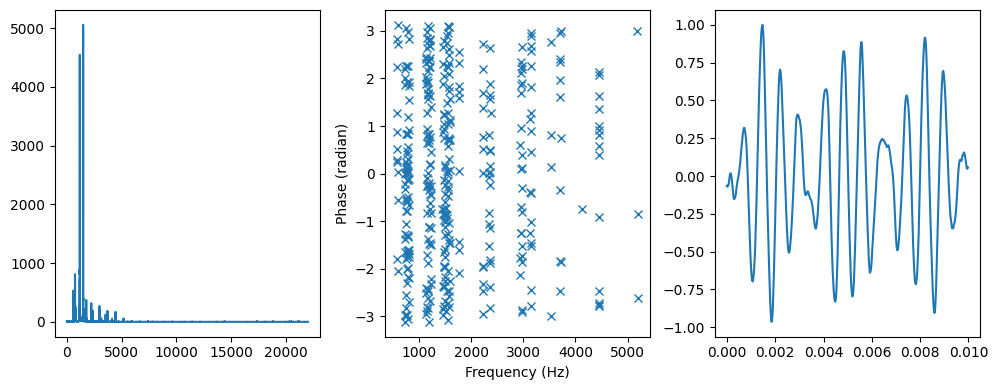

In [94]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

Как можно услышать из получившегося аудио, после применения функции звук изменил свою "форму", стал монотонным и, будто, "размножился", однако исходная мелодия гобоя угадывается.

В итоге сравнения данного аудио фрагмента и пилообразного сигнала, мы видим, что на музыку функция зануления угла и случайного угла произвели какой-то заметный эффект.


Повторим опыты над звуком саксофона.

Выведем на экран графики для этого сегмента:


In [95]:
wave = read_wave('100475__iluppai__saxophone-weep.wav')
wave.make_audio()
segment = wave.segment(start=3, duration=0.6)

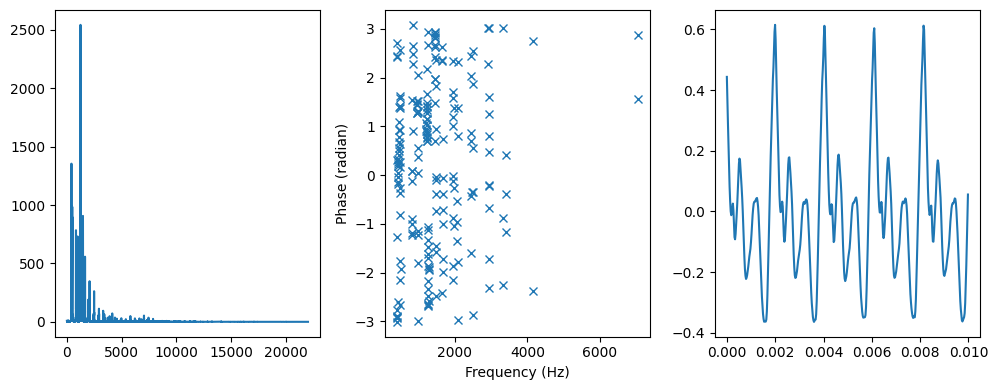

In [96]:
spectrum = segment.make_spectrum()
plot_three(spectrum, thresh=50)

Вызовем функцию zero_angle и посмотрим на результат:

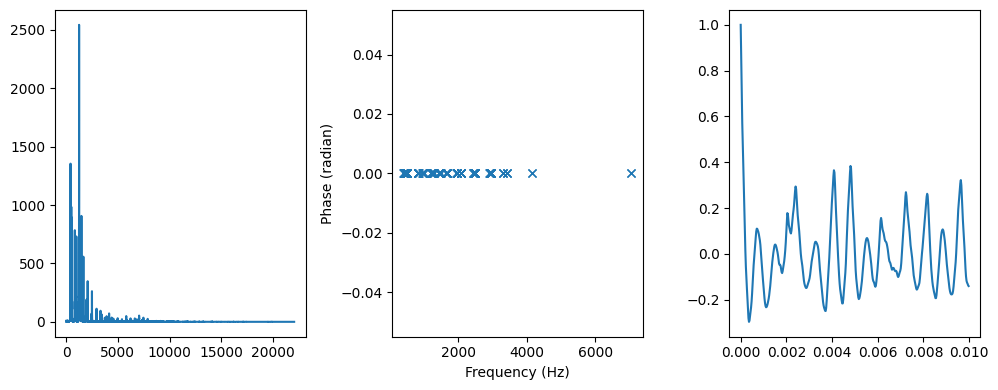

In [97]:
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

Звук изменил свою «форму» и стал тише.

На протяжении всего времени записи сегмент монотонный, но ближе к концу становится громче, чего в изначальном варианте не было.


Теперь попробуем вызвать функцию rotate_angle:


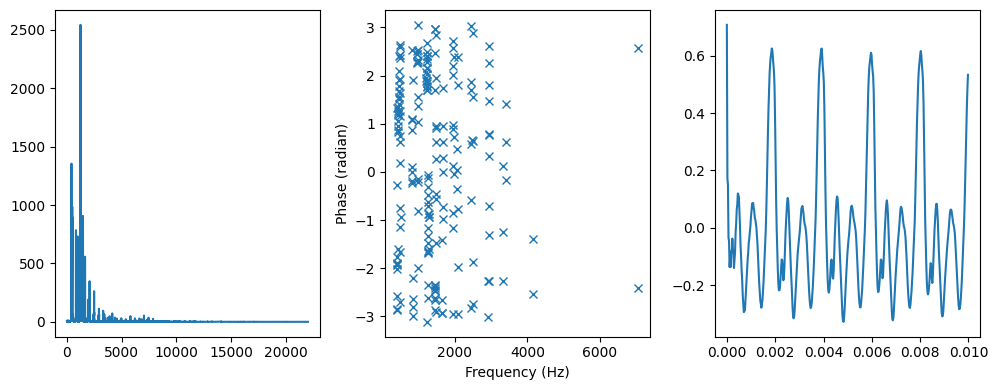

In [98]:
spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3, thresh=50)

После использования данной функции, как мы слышим, звук снова совсем не изменился.


Рассмотрим, как изменится звук после функции random_angle:


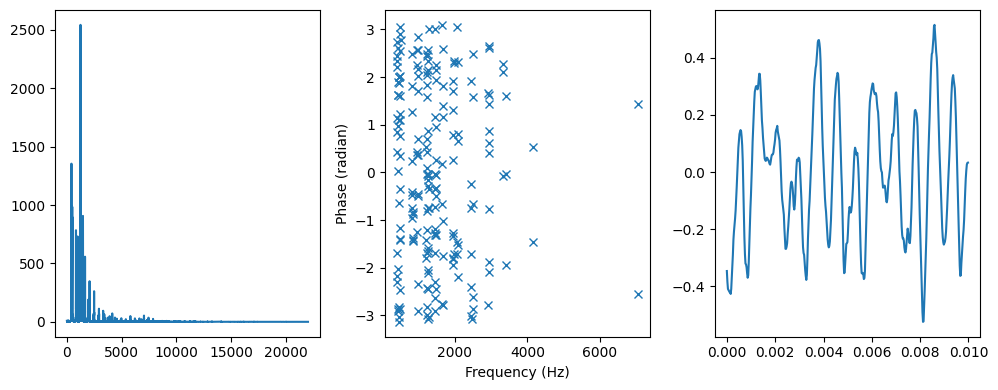

In [99]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

Изменения в звуке после вызова функции выражаются в том, что он снова стал более монотонным и будто "размножился", сейчас он больше похож на гудок машины.

Как мы узнали в предыдущих упражнениях в звуке саксофона слышимая частота не является доминирующей. Добавим фильтр низких частот, чтоб создать явление подавленной основной. Возможно, этот звук более чувствителен к фазовой структуре.

Убедимся, что частоты ниже 600 удалены:


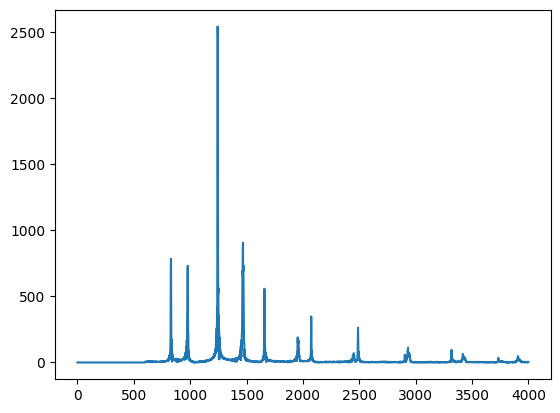

In [100]:
spectrum.high_pass(600)
spectrum.plot(high=4000)

Выведем все неободимые графики для нового фрагмента:

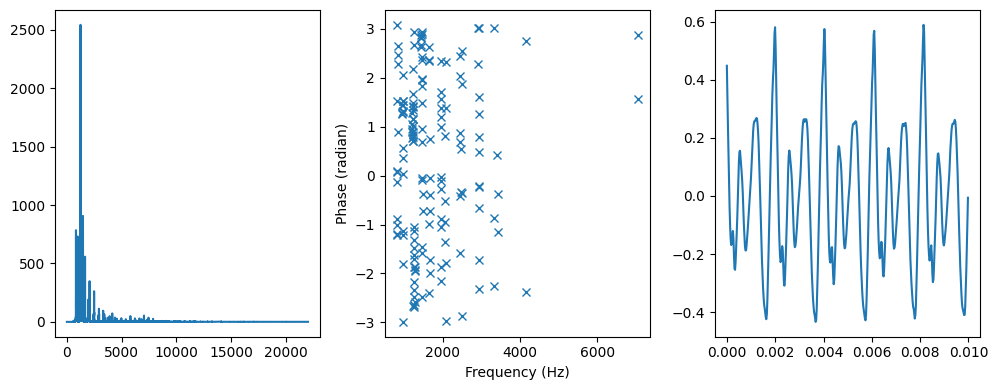

In [101]:
plot_three(spectrum, thresh=50)

Видим, что графики не сильно изменились, то же самое можно сказать и о звуке.

Теперь применим функцию zero_angle:


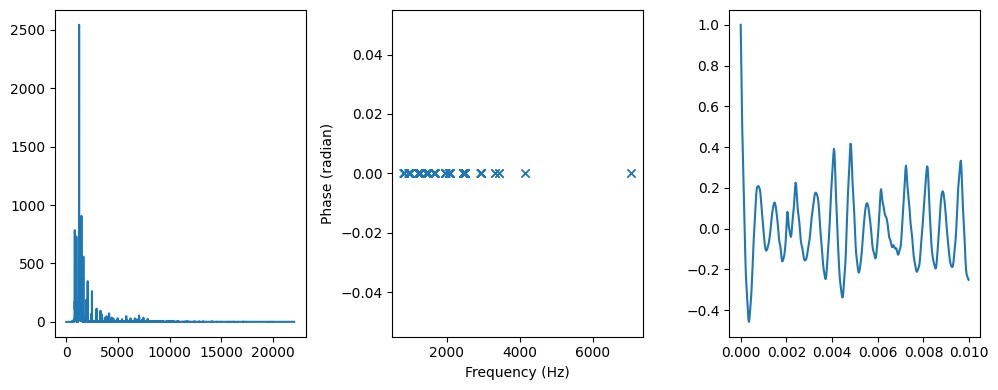

In [102]:
spectrum2 = zero_angle(spectrum)
plot_three(spectrum2, thresh=50)

В этот раз звук изменился чуть меньше, нежели до фильтра низких частот, однако все равно видно и слышно изменение «формы» сигнала.

Перейдем к функции rotate_angle, которая в прошлый раз практически не изменила сигнал по звучанию:

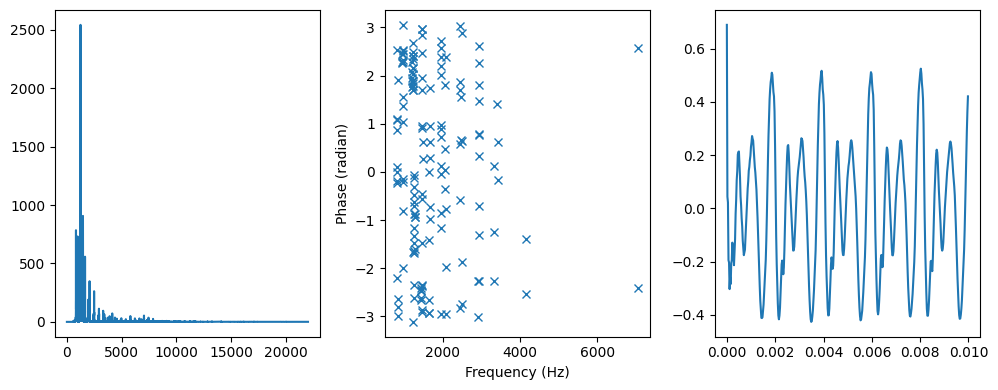

In [103]:
spectrum3 = rotate_angle(spectrum, 1)
plot_three(spectrum3, thresh=50)

Как и ожидалось, звук не изменился.

Наконец, применим функцию random_angle:

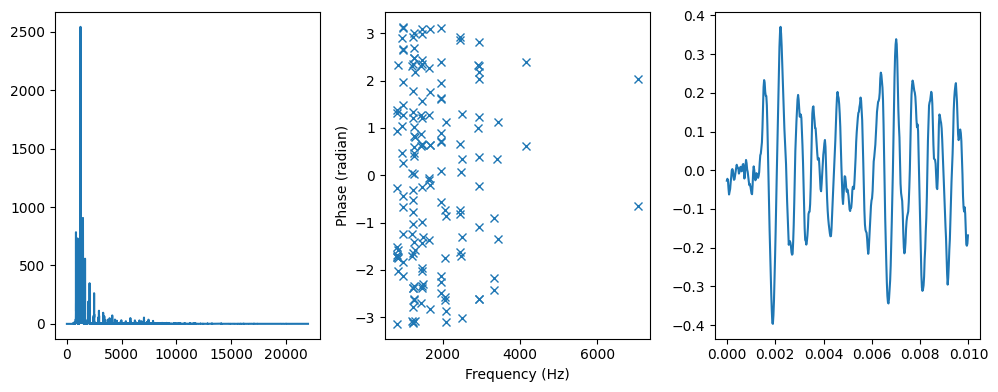

In [104]:
spectrum4 = random_angle(spectrum)
plot_three(spectrum4, thresh=50)

Звук опять стал более монотонным и будто "размножился".

По итогам сравнния нескольких звуковых сигналов делаем вывод, что мы способны различить монотонность, громкость, частоту звука, но мы слышим только значительные изменения в фазовой структуре.

Именно поэтому результаты большинства функций, применённых нами в данной работе, показались нашему слуху идентичными исходным отрывкам.
